In [1]:
foldername = '/home/edavenport/analysis/vel-assim-manuscript/forecasts/results_figs/skill/'

In [2]:
import sys, os
sys.path.insert(0, os.path.dirname(os.path.abspath('.')))
import pandas as pd
import numpy as np
from forecasts.forecast_utils import get_forecast_params

# ═══════════════════════════════════════════════════════════════════
#  FORECAST PARAMETERS — only change start_date to switch forecasts
#  Supported range: Sep 2012 – Jul 2013 (1st of month)
# ═══════════════════════════════════════════════════════════════════
start_date = pd.Timestamp('2013-03-01')

# TPOSE-Vel state estimate directory (varies by run; set manually for each forecast)
vel_estimate_data_dir = '/data/SO3/edavenport/tpose6/mar2013/run_iter16/'

p = get_forecast_params(start_date)

# ── Unpack for use in subsequent cells ───────────────────────────
start_date  = p.start_date
end_date    = p.end_date
month_str   = p.month_str
day_str     = p.day_str
year_str    = p.year_str

noTAO_data_dir          = p.noTAO_data_dir
noTAO_forecast_data_dir = p.noTAO_forecast_data_dir
vel_forecast_data_dir   = p.vel_forecast_data_dir
grid_dir                = p.grid_dir

ref_date        = p.ref_date
itPerFile       = p.itPerFile
delta_t         = p.delta_t
num_diags       = p.num_diags
intervals       = p.intervals
n_forecast_days = p.n_forecast_days
n_eval          = p.n_eval
eval_slice      = p.eval_slice
eval_start_date = p.eval_start_date
days            = p.days
eval_dates      = p.eval_dates
eval_months     = p.eval_months
month_bounds    = p.month_bounds
month_centers   = p.month_centers

print(f'Forecast     : {start_date.date()} → {end_date.date()} ({n_forecast_days} days)')
print(f'Eval months  : {eval_months}')
print(f'itPerFile    : {itPerFile}  |  delta_t: {delta_t:.0f} s')
print(f'noTAO est dir: {noTAO_data_dir}')
print(f'noTAO fct dir: {noTAO_forecast_data_dir}')
print(f'Vel est dir  : {vel_estimate_data_dir}')
print(f'Vel fct dir  : {vel_forecast_data_dir}')

Forecast     : 2013-03-01 → 2013-06-30 (121 days)
Eval months  : [3, 4, 5, 6]
itPerFile    : 72  |  delta_t: 1200 s
noTAO est dir: /data/SO3/averdy/TPOSE6/mar2013/diags_daily/
noTAO fct dir: /data/SO3/edavenport/tpose6/forecasts/mar012013_tpose_noVel/
Vel est dir  : /data/SO3/edavenport/tpose6/mar2013/run_iter16/
Vel fct dir  : /data/SO3/edavenport/tpose6/forecasts/mar012013/


### Load TPOSE Estimates and Forecasts

In [3]:
import matplotlib.pyplot as plt
import cmocean.cm as cmo
import xarray as xr
from xmitgcm import open_mdsdataset
plt.rcParams['font.size'] = 14

prefix = ['diag_surf']

def open_tpose(data_dir):
    ds = open_mdsdataset(
        data_dir=data_dir, grid_dir=grid_dir,
        iters=intervals, prefix=prefix, ref_date=ref_date, delta_t=delta_t)
    for coord in ['XC', 'YC', 'Z', 'XG', 'YG']:
        ds[coord] = ds[coord].astype(float)
    return ds

### TPOSE-noVel State Estimate
ds_tpose_noTAO = open_tpose(noTAO_data_dir)

### TPOSE-noVel Forecast
ds_tpose_noTAO_forecast = open_tpose(noTAO_forecast_data_dir)

### TPOSE-Vel State Estimate
ds_tpose_vel = open_tpose(vel_estimate_data_dir)

### TPOSE-Vel Forecast
ds_tpose_vel_forecast = open_tpose(vel_forecast_data_dir)

### Load AVISO climatology and GLORYS

Aviso is monthly climatology caculated from 2010 to 2020 (i.e.. it is the monthly mean and std deviation at each point over that time)

In [4]:
from forecasts.forecast_utils import load_hycom_daily

aviso  = xr.open_dataset('forecasts/aviso_data/aviso_climatology_1993to2012.nc')
glorys = xr.open_mfdataset('/data/SO3/edavenport/tpose6/glorys_data/glorys_*.nc', combine='by_coords')
hycom  = load_hycom_daily(start_date, end_date)   # None if no files exist for this window

glory = glorys.sel(time=slice(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')))

if hycom is None:
    print('WARNING: No HYCOM data available for this forecast window — HYCOM will be omitted from figures.')

### Compare Skill

In [5]:
lonMin = 180
lonMax = 260
latMin = -10
latMax = 10
zMin = -500
zMax = 0

### SSH RMSE vs AVISO

In [6]:
# Load AVISO ADT (Absolute Dynamic Topography = total SSH) for comparison
# Convert longitude from -180:180 to 0:360 to match TPOSE convention
aviso_obs = xr.open_dataset('forecasts/aviso_data/aviso_equatorial_pacific.nc',
                             chunks={'time': 10})
aviso_obs = aviso_obs.assign_coords(longitude=(aviso_obs.longitude % 360)).sortby('longitude')

aviso_full = aviso_obs.adt.sel(
    time=slice(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
    latitude=slice(latMin, latMax),
    longitude=slice(lonMin, lonMax)
).compute()

# ── GLORYS SSH (zos) ──────────────────────────────────────────────────────────
glorys_region = glorys.assign_coords(
    longitude=(glorys.longitude % 360)
).sortby('longitude')
glorys_full = glorys_region.zos.sel(
    time=slice(start_date.strftime('%Y-%m-%d'), end_date.strftime('%Y-%m-%d')),
    latitude=slice(latMin, latMax),
    longitude=slice(lonMin, lonMax)
).compute()

# ── HYCOM SSH (surf_el) — skipped if no data for this window ──────────────────
if hycom is not None:
    hycom_region = hycom.assign_coords(lon=(hycom.lon % 360)).sortby('lon')
    hycom_full = hycom_region.surf_el.sel(
        lat=slice(latMin, latMax),
        lon=slice(lonMin, lonMax)
    ).compute()

In [7]:
# ── Load TPOSE and interpolate AVISO/GLORYS/HYCOM to TPOSE grid ───────────────
def load_etan(ds):
    return ds.ETAN.sel(XC=slice(lonMin, lonMax), YC=slice(latMin, latMax)).isel(time=eval_slice).compute()

tpose_noTAO_eval         = load_etan(ds_tpose_noTAO)
tpose_noTAO_fct_eval     = load_etan(ds_tpose_noTAO_forecast)
tpose_vel_est_eval       = load_etan(ds_tpose_vel)
tpose_vel_eval           = load_etan(ds_tpose_vel_forecast)

tpose_xc = tpose_noTAO_eval.XC.values
tpose_yc = tpose_noTAO_eval.YC.values

aviso_eval  = aviso_full.isel(time=eval_slice).interp(longitude=tpose_xc, latitude=tpose_yc, method='linear')
glorys_eval = glorys_full.isel(time=eval_slice).interp(longitude=tpose_xc, latitude=tpose_yc, method='linear')

# Remove a single scalar (domain + time mean) from each product to align reference levels
aviso_anom           = aviso_eval           - float(aviso_eval.mean())
tpose_noTAO_anom     = tpose_noTAO_eval     - float(tpose_noTAO_eval.mean())
tpose_noTAO_fct_anom = tpose_noTAO_fct_eval - float(tpose_noTAO_fct_eval.mean())
tpose_vel_est_anom   = tpose_vel_est_eval   - float(tpose_vel_est_eval.mean())
tpose_vel_anom       = tpose_vel_eval       - float(tpose_vel_eval.mean())
glorys_anom          = glorys_eval          - float(glorys_eval.mean())

if hycom is not None:
    hycom_eval  = hycom_full.isel(time=eval_slice).interp(lon=tpose_xc, lat=tpose_yc, method='linear')
    hycom_anom  = hycom_eval - float(hycom_eval.mean())

# ── Latitude-weighted spatial RMSE ────────────────────────────────────────────
lat_weights = np.cos(np.deg2rad(tpose_yc))
lat_weights_2d = lat_weights[:, np.newaxis] * np.ones(len(tpose_xc))
lat_weights_norm = lat_weights_2d / np.nansum(lat_weights_2d)

def spatial_rmse(model_vals, obs_vals):
    """Weighted spatial RMSE; shape (n_time, n_lat, n_lon) → (n_time,)."""
    diff = model_vals - obs_vals
    return np.sqrt(np.nansum(diff**2 * lat_weights_norm, axis=(1, 2)))

aviso_vals           = aviso_anom.values
rmse_noTAO           = spatial_rmse(tpose_noTAO_anom.values,     aviso_vals)
rmse_noTAO_forecast  = spatial_rmse(tpose_noTAO_fct_anom.values, aviso_vals)
rmse_vel_estimate    = spatial_rmse(tpose_vel_est_anom.values,    aviso_vals)
rmse_vel             = spatial_rmse(tpose_vel_anom.values,        aviso_vals)
rmse_glorys          = spatial_rmse(glorys_anom.values,           aviso_vals)

if hycom is not None:
    rmse_hycom = spatial_rmse(hycom_anom.values, aviso_vals)

# Persistence: initial field (day 1) from each forecast held constant for all n_eval days
def persistence_rmse(anom):
    field = anom.isel(time=0).values
    return spatial_rmse(np.broadcast_to(field, (n_eval,) + field.shape), aviso_vals)

rmse_noTAO_fct_persistence = persistence_rmse(tpose_noTAO_fct_anom)
rmse_vel_persistence       = persistence_rmse(tpose_vel_anom)

# ── Climatology baseline: area-weighted RMS of adt_std per calendar month ─────
# sqrt(weighted_mean(σ²)) matches the same L2 norm used by spatial_rmse
aviso_clim_conv = aviso.assign_coords(longitude=(aviso.longitude % 360)).sortby('longitude')
clim_region = aviso_clim_conv.adt_std.sel(latitude=slice(latMin, latMax), longitude=slice(lonMin, lonMax))

clim_lat_w = np.cos(np.deg2rad(clim_region.latitude.values))
clim_lat_w_2d = clim_lat_w[:, np.newaxis] * np.ones(len(clim_region.longitude))
clim_lat_w_norm = clim_lat_w_2d / np.nansum(clim_lat_w_2d)

month_baseline = {m: float(np.sqrt(np.nansum(clim_region.sel(month=m).values**2 * clim_lat_w_norm)))
                  for m in eval_months}

eval_dates_ts = pd.date_range(eval_start_date, periods=n_eval)
baseline_ts = np.array([month_baseline[d.month] for d in eval_dates_ts])

for m in eval_months:
    print(f'Month {m} ADT sigma_clim baseline: {month_baseline[m]*100:.2f} cm')

Month 3 ADT sigma_clim baseline: 6.29 cm
Month 4 ADT sigma_clim baseline: 5.94 cm
Month 5 ADT sigma_clim baseline: 5.67 cm
Month 6 ADT sigma_clim baseline: 5.80 cm


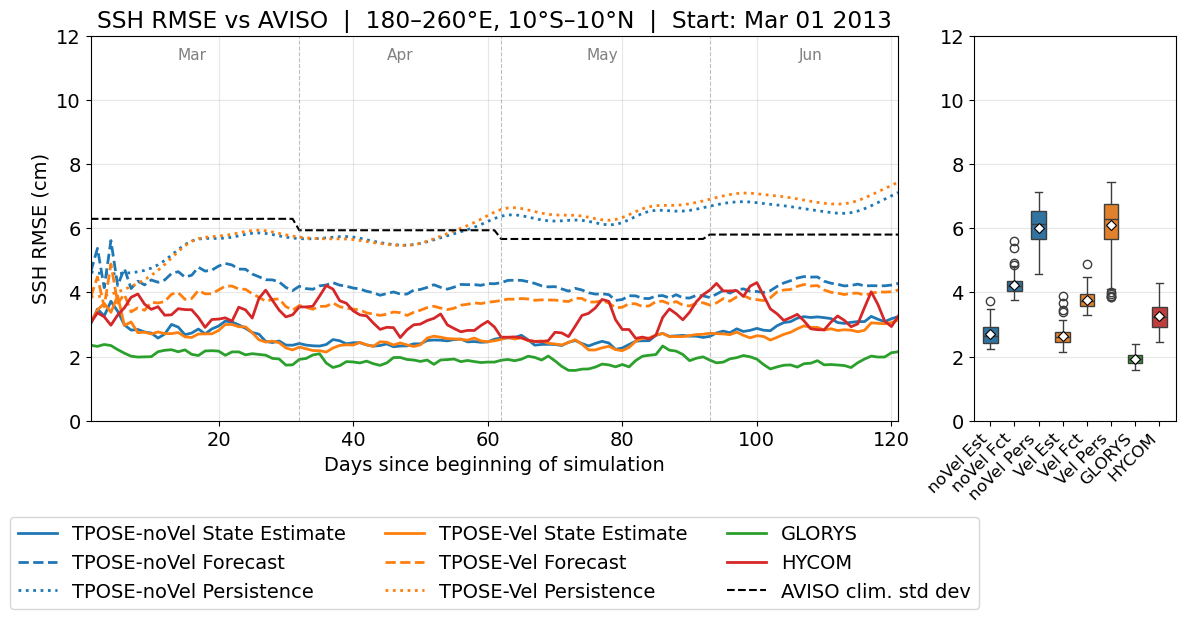

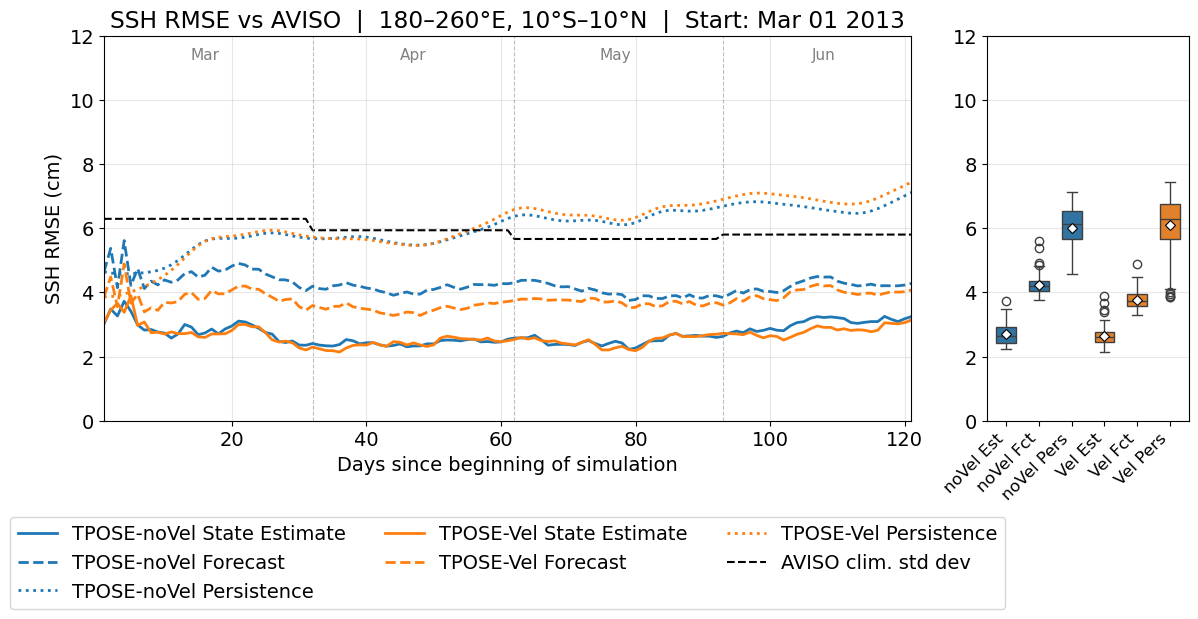

In [8]:
import seaborn as sns
import matplotlib.gridspec as gridspec

ylim = (0, 12)

# Each entry: (data_cm, long_label, short_label, color, linestyle)
datasets_all = [
    (rmse_noTAO * 100,                'TPOSE-noVel State Estimate', 'noVel Est',  'C0', '-'),
    (rmse_noTAO_forecast * 100,       'TPOSE-noVel Forecast',       'noVel Fct',  'C0', '--'),
    (rmse_noTAO_fct_persistence * 100,'TPOSE-noVel Persistence',    'noVel Pers', 'C0', ':'),
    (rmse_vel_estimate * 100,         'TPOSE-Vel State Estimate',   'Vel Est',    'C1', '-'),
    (rmse_vel * 100,                  'TPOSE-Vel Forecast',         'Vel Fct',    'C1', '--'),
    (rmse_vel_persistence * 100,      'TPOSE-Vel Persistence',      'Vel Pers',   'C1', ':'),
    (rmse_glorys * 100,               'GLORYS',                     'GLORYS',     'C2', '-'),
]
if hycom is not None:
    datasets_all.append((rmse_hycom * 100, 'HYCOM', 'HYCOM', 'C3', '-'))

datasets_tpose = datasets_all[:6]

for datasets, suffix in [(datasets_all, ''), (datasets_tpose, '_tpose_only')]:
    short_names = [ds[2] for ds in datasets]
    palette     = [ds[3] for ds in datasets]

    fig = plt.figure(figsize=(14, 5))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[4, 1], wspace=0.15)
    ax  = fig.add_subplot(gs[0])
    ax_b = fig.add_subplot(gs[1])

    # ── Time series ───────────────────────────────────────────────
    for data, long_name, _, color, ls in datasets:
        ax.plot(days, data, color=color, lw=2, ls=ls, label=long_name)
    ax.plot(days, baseline_ts * 100, color='k', lw=1.5, ls='--', label='AVISO clim. std dev')

    for d in month_bounds.values():
        ax.axvline(d, color='gray', lw=0.8, linestyle='--', alpha=0.5)
    for mname, xpos in month_centers:
        ax.text(xpos, ylim[1] * 0.97, mname, ha='center', va='top', color='gray', fontsize=11)

    ax.set_xlabel('Days since beginning of simulation')
    ax.set_ylabel('SSH RMSE (cm)')
    ax.set_title(f'SSH RMSE vs AVISO  |  180–260°E, 10°S–10°N  |  Start: {start_date.strftime("%b %d %Y")}')
    ax.set_xlim(days[0], days[-1])
    ax.set_ylim(ylim)
    ax.grid(alpha=0.3)

    # matplotlib fills legends column-major (top→bottom within each column), so with ncol=3
    # the handle order [noVel×3, Vel×3, others] naturally groups each set into its own column.
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.25), ncol=3, borderaxespad=0)

    # ── IQR summary column ────────────────────────────────────────
    ts_data   = [ds[0] for ds in datasets]
    col_names = [f'ds{k}' for k in range(len(ts_data))]
    box_df    = pd.DataFrame({n: pd.Series(d) for n, d in zip(col_names, ts_data)})
    pal_dict  = dict(zip(col_names, palette))
    sns.boxplot(data=box_df, ax=ax_b, palette=pal_dict, width=0.6)
    for k, d in enumerate(ts_data):
        ax_b.plot(k, np.nanmean(d), marker='D', ms=5, color='white', mec='black', mew=0.8, zorder=5)
    ax_b.set_xticks(range(len(short_names)))
    ax_b.set_xticklabels(short_names, fontsize=12, rotation=45, ha='right')
    ax_b.set_ylabel('')
    ax_b.set_ylim(ylim)
    ax_b.grid(alpha=0.3, axis='y')

    plt.savefig(foldername + f'ssh_rmse_vs_aviso_{month_str}{day_str}{year_str}{suffix}.png',
                dpi=150, bbox_inches='tight')
    plt.show()